# Time Series Analysis: ESN Porto Student Registrations

**Group 26**
- Adriano Machado
- Francisco da Ana
- João Lopes
- Tiago Teixeira

This analysis examines ESN (Erasmus Student Network) card registration patterns from international students in Porto, spanning academic years 2020-2021 through 2025-2026. The data captures the moment students activate their ESN membership, allowing the analysis of international student arrival dynamics.

The dataset comes from ESN Porto's administrative records of ESNcard activations. The ESNcard is a membership card that international students typically purchase when they arrive in Porto, giving them access to various discounts and benefits. The data primarily reflects Erasmus and other exchange students studying at Porto's universities.

In [2]:
import json
import pandas as pd
from pathlib import Path

In [3]:
data_dir = Path('data')

# Load the JSON file
with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"Loaded data from: {data_dir / 'eventupp_students_private.json'}")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded data from: data/eventupp_students_private.json
Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']


In [4]:
# Convert registerDate from milliseconds to datetime
df['registerDate'] = pd.to_datetime(df['registerDate'], unit='ms')

# Set registerDate as index for time series operations
df_ts = df.set_index('registerDate').sort_index()

# Aggregate weekly - count registrations per week
weekly_registrations = df_ts.resample('W').size()

# Create a DataFrame with weekly aggregation
weekly_df = pd.DataFrame({
    'week_ending': weekly_registrations.index,
    'registrations': weekly_registrations.values
})

print(f"\nWeekly aggregation:")
print(f"Total weeks: {len(weekly_df)}")
print(f"Date range: {weekly_df['week_ending'].min()} to {weekly_df['week_ending'].max()}")
print(f"\nFirst 10 weeks:")
print(weekly_df.head(10))
print(f"\nSummary statistics:")
print(weekly_df['registrations'].describe())

# Save to JSON file
output_file = data_dir / 'weekly_students.json'
weekly_df.to_json(output_file, orient='records', date_format='iso', indent=2)
print(f"\nSaved weekly data to: {output_file}")



Weekly aggregation:
Total weeks: 227
Date range: 2021-08-08 00:00:00 to 2025-12-07 00:00:00

First 10 weeks:
  week_ending  registrations
0  2021-08-08             17
1  2021-08-15             22
2  2021-08-22             15
3  2021-08-29             18
4  2021-09-05            196
5  2021-09-12            246
6  2021-09-19            190
7  2021-09-26            145
8  2021-10-03            172
9  2021-10-10             71

Summary statistics:
count    227.000000
mean      62.414097
std      105.141184
min        0.000000
25%        7.500000
50%       22.000000
75%       60.000000
max      638.000000
Name: registrations, dtype: float64

Saved weekly data to: data/weekly_students.json


Saved plot to: weekly_registrations.png


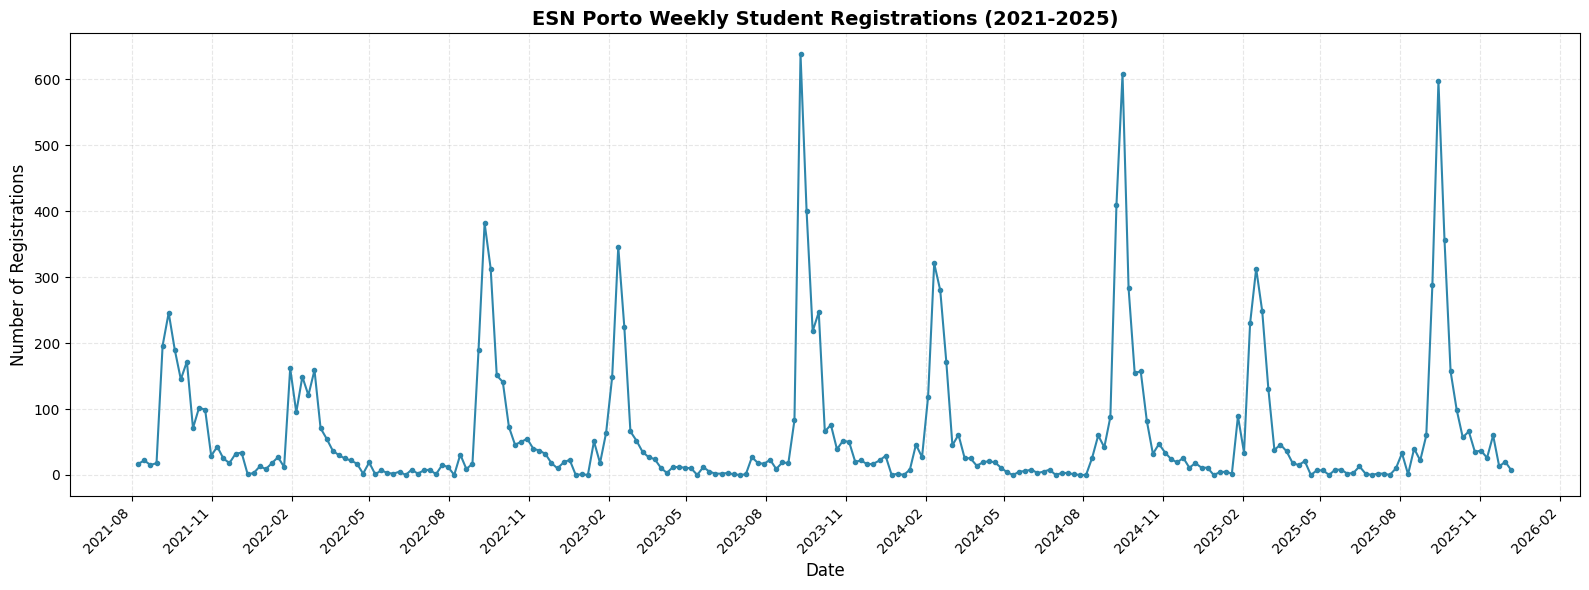

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(weekly_df['week_ending'], weekly_df['registrations'], 
        linewidth=1.5, color='#2E86AB', marker='o', markersize=3)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Registrations', fontsize=12)
ax.set_title('ESN Porto Weekly Student Registrations (2021-2025)', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

plot_file = Path('weekly_registrations.png')
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"Saved plot to: {plot_file}")

plt.show()

In [6]:
def create_features(df):
    df = df.copy()

    df['month'] = df['week_ending'].dt.month
    df['year'] = df['week_ending'].dt.year
    df['week_of_year'] = df['week_ending'].dt.isocalendar().week.astype(int)

    # Calculate week of month (0-5)
    df['day_of_month'] = df['week_ending'].dt.day
    df['week_of_month'] = ((df['day_of_month'] - 1) // 7)

    # Is welcome month (February=2 or September=9)
    df['is_welcome_month'] = ((df['month'] == 2) | (df['month'] == 9)).astype(int)

    # Semester: 0 for fall (Aug-Jan), 1 for spring (Feb-Jul)
    df['semester'] = ((df['month'] >= 2) & (df['month'] <= 7)).astype(int)

    # Week of semester calculation
    def calculate_week_of_semester(row):
        year = row['year']
        month = row['month']
        week_ending = row['week_ending']

        if month >= 8:  # Fall semester (Aug-Dec)
            semester_start = pd.Timestamp(year=year, month=8, day=1)
        elif month <= 7 and month >= 2:  # Spring semester (Feb-Jul)
            semester_start = pd.Timestamp(year=year, month=2, day=1)
        else:  # January (still fall semester of previous academic year)
            semester_start = pd.Timestamp(year=year-1, month=8, day=1)

        weeks_diff = (week_ending - semester_start).days // 7
        return max(0, weeks_diff)

    df['week_of_semester'] = df.apply(calculate_week_of_semester, axis=1)

    # Lag features
    df['lag1'] = df['registrations'].shift(1)
    df['lag2'] = df['registrations'].shift(2)

    # Rolling average of last 4 weeks
    df['avg_last_4'] = df['registrations'].shift(1).rolling(window=4, min_periods=1).mean()

    # Lag of 1 year ago (52 weeks)
    df['lag_52'] = df['registrations'].shift(52)

    return df

# Apply features
df_features = create_features(weekly_df)
print("Features created.")

Features created.


In [8]:
df_features.head()

,week_ending,registrations,month,year,week_of_year,day_of_month,week_of_month,is_welcome_month,semester,week_of_semester,lag1,lag2,avg_last_4,lag_52
0,2021-08-08,17,8,2021,31,8,1,0,0,1,NaN,NaN,NaN,NaN
1,2021-08-15,22,8,2021,32,15,2,0,0,2,17.0,NaN,17.0,NaN
2,2021-08-22,15,8,2021,33,22,3,0,0,3,22.0,17.0,19.5,NaN
3,2021-08-29,18,8,2021,34,29,4,0,0,4,15.0,22.0,18.0,NaN
4,2021-09-05,196,9,2021,35,5,0,1,0,5,18.0,15.0,18.0,NaN


In [9]:
feature_cols = [
    'is_welcome_month', 'semester', 'month', 'week_of_year', 
    'week_of_month', 'week_of_semester', 'lag1', 'lag2', 
    'avg_last_4', 'lag_52'
]

# Drop NaNs created by lag features
df_clean = df_features.dropna(subset=feature_cols).copy()

# Split Data
TEST_YEAR = 2025
train_df = df_clean[df_clean['year'] < TEST_YEAR].copy()
test_df = df_clean[df_clean['year'] >= TEST_YEAR].copy()

# Separate X and y
X_train = train_df[feature_cols]
y_train = train_df['registrations']
X_test = test_df[feature_cols]
y_test = test_df['registrations']

print(f"Training Data: {len(X_train)} weeks (2021-2024)")
print(f"Test Data:     {len(X_test)} weeks (2025)")

Training Data: 126 weeks (2021-2024)
Test Data:     49 weeks (2025)


In [11]:
from pathlib import Path
from datetime import datetime, timedelta
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tscv = TimeSeriesSplit(n_splits=5)

cv_metrics = {'mae': [], 'rmse': [], 'maape': []}

print("Running Expanding Window CV...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    # Slice data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train
    model_cv = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6, 
        loss_function='RMSE', random_seed=42, verbose=False
    )
    model_cv.fit(X_fold_train, y_fold_train)
    
    # Predict
    y_pred_cv = model_cv.predict(X_fold_val)
    
    # Metrics
    mae = np.mean(np.abs(y_fold_val - y_pred_cv))
    rmse = np.sqrt(np.mean((y_fold_val - y_pred_cv) ** 2))
    maape = np.mean(np.arctan(np.abs((y_fold_val - y_pred_cv) / (y_fold_val + 1e-10)))) * 100
    
    cv_metrics['mae'].append(mae)
    cv_metrics['rmse'].append(rmse)
    cv_metrics['maape'].append(maape)
    
    # Dates for context
    val_start = train_df.iloc[val_idx]['week_ending'].min().strftime('%Y-%m')
    print(f"Fold {fold+1} (Val: {val_start}): MAE={mae:.2f}, RMSE={rmse:.2f}")

print("\nAverage CV Results:")
print(f"MAE:  {np.mean(cv_metrics['mae']):.2f} ± {np.std(cv_metrics['mae']):.2f}")
print(f"RMSE: {np.mean(cv_metrics['rmse']):.2f} ± {np.std(cv_metrics['rmse']):.2f}")

Running Expanding Window CV...

Fold 1 (Val: 2023-01): MAE=34.67, RMSE=53.34
Fold 2 (Val: 2023-05): MAE=46.98, RMSE=95.01
Fold 3 (Val: 2023-10): MAE=22.26, RMSE=28.98
Fold 4 (Val: 2024-03): MAE=8.67, RMSE=10.69
Fold 5 (Val: 2024-08): MAE=35.59, RMSE=64.07

Average CV Results:
MAE:  29.63 ± 13.08
RMSE: 50.42 ± 29.06


In [12]:
# Initialize final model
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

# Fit on ALL training data
final_model.fit(X_train, y_train)

# Generate predictions
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

print("Final model trained and predictions generated.")

Final model trained and predictions generated.


In [13]:
def get_metrics(y_true, y_pred, set_name="Test"):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    maape = np.mean(np.arctan(np.abs((y_true - y_pred) / (y_true + 1e-10)))) * 100
    
    print(f"--- {set_name} Set Metrics ---")
    print(f"MAE:   {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAAPE: {maape:.2f}%")
    return mae, rmse, maape

_ = get_metrics(y_train, y_pred_train, "Train")
print("")
mae_test, rmse_test, maape_test = get_metrics(y_test, y_pred_test, "Test (2025)")

--- Train Set Metrics ---
MAE:   2.86
RMSE:  3.44
MAAPE: 30.44%

--- Test (2025) Set Metrics ---
MAE:   26.17
RMSE:  46.82
MAAPE: 58.60%


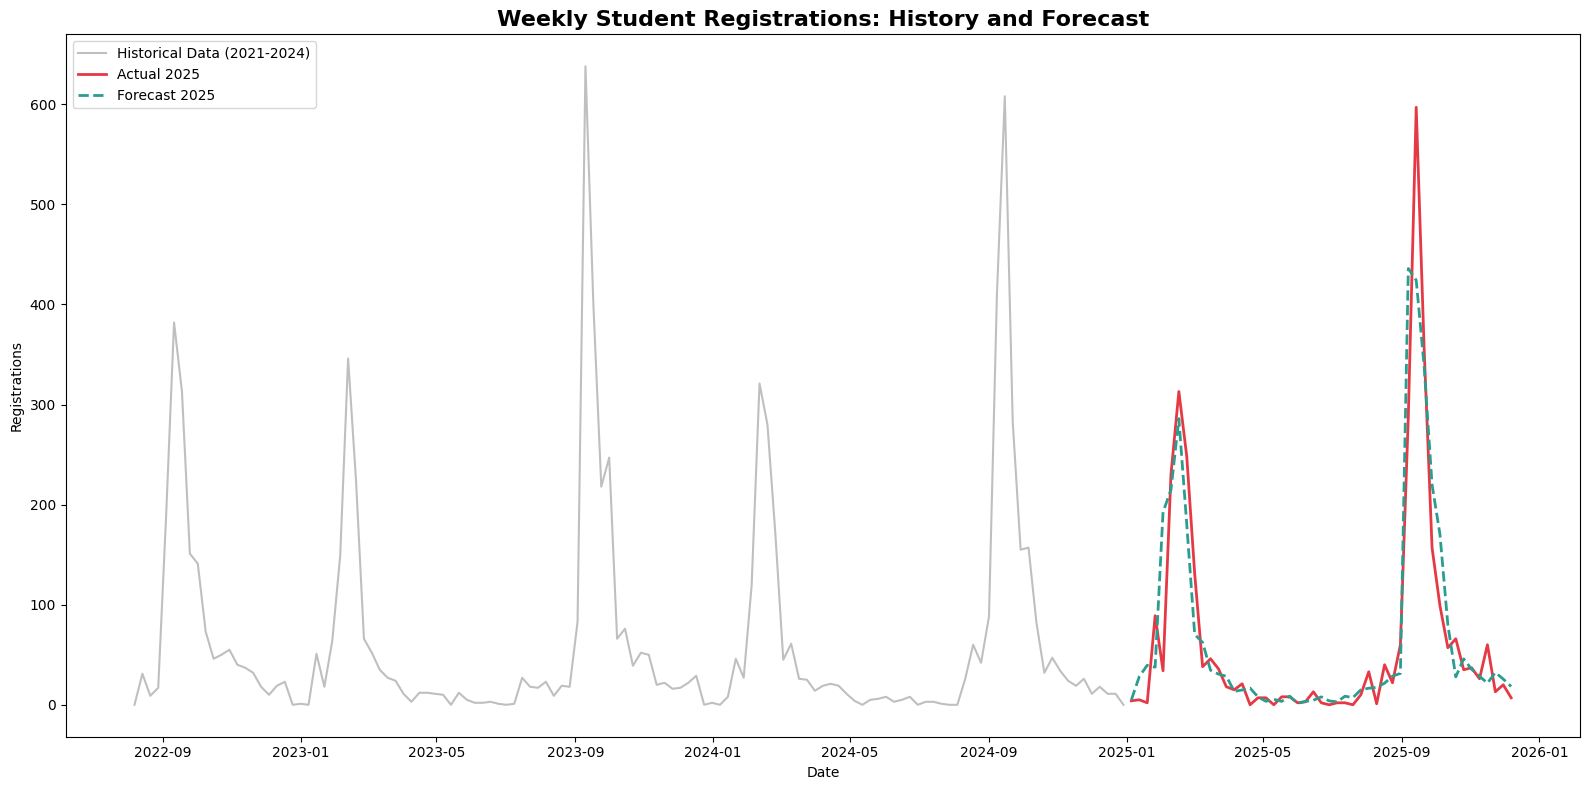

In [14]:
plt.figure(figsize=(16, 8))

plt.plot(train_df['week_ending'], train_df['registrations'], 
         label='Historical Data (2021-2024)', color='grey', alpha=0.5)

plt.plot(test_df['week_ending'], test_df['registrations'], 
         label='Actual 2025', color='#E63946', linewidth=2)

plt.plot(test_df['week_ending'], y_pred_test, 
         label='Forecast 2025', color='#2A9D8F', linestyle='--', linewidth=2)

plt.title('Weekly Student Registrations: History and Forecast', fontsize=16, fontweight='bold')
plt.ylabel('Registrations')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

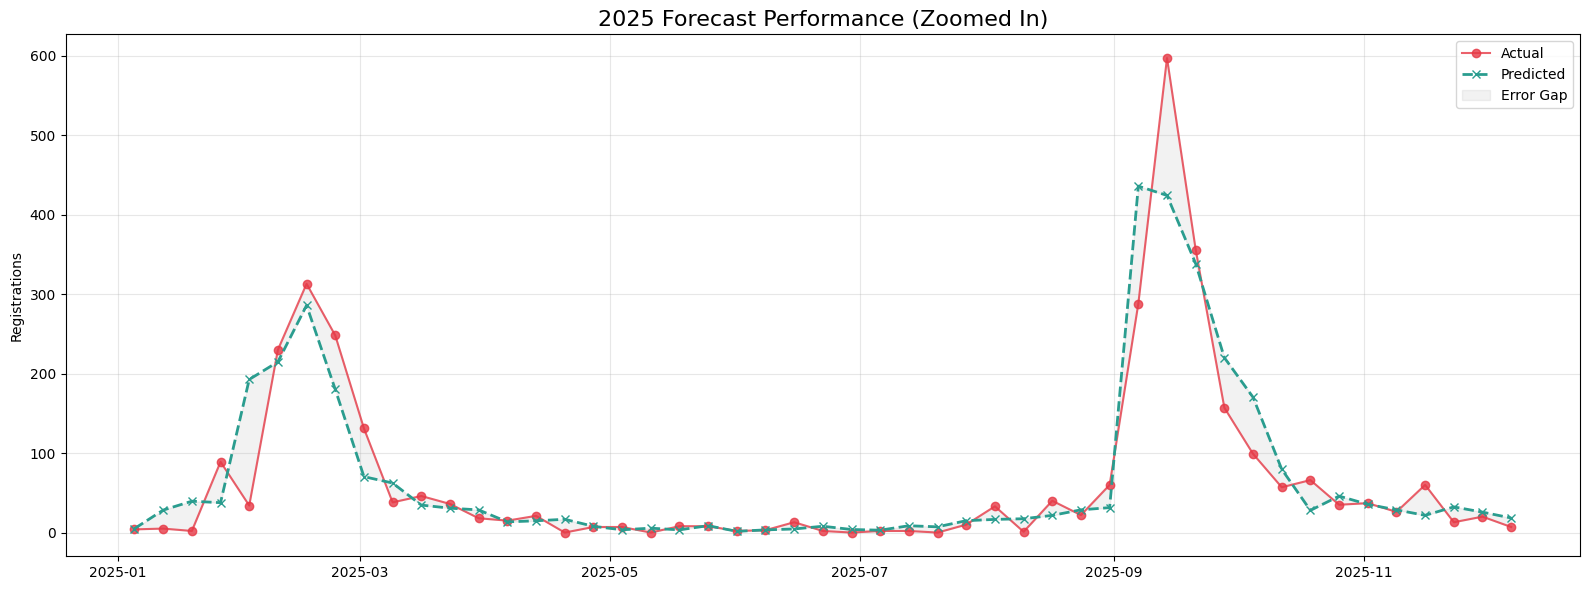

In [15]:
plt.figure(figsize=(16, 6))

plt.plot(test_df['week_ending'], test_df['registrations'], 
         label='Actual', color='#E63946', marker='o', alpha=0.8)
plt.plot(test_df['week_ending'], y_pred_test, 
         label='Predicted', color='#2A9D8F', linestyle='--', marker='x', linewidth=2)

plt.fill_between(test_df['week_ending'], 
                 test_df['registrations'], y_pred_test, 
                 color='gray', alpha=0.1, label='Error Gap')

plt.title('2025 Forecast Performance (Zoomed In)', fontsize=16)
plt.ylabel('Registrations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

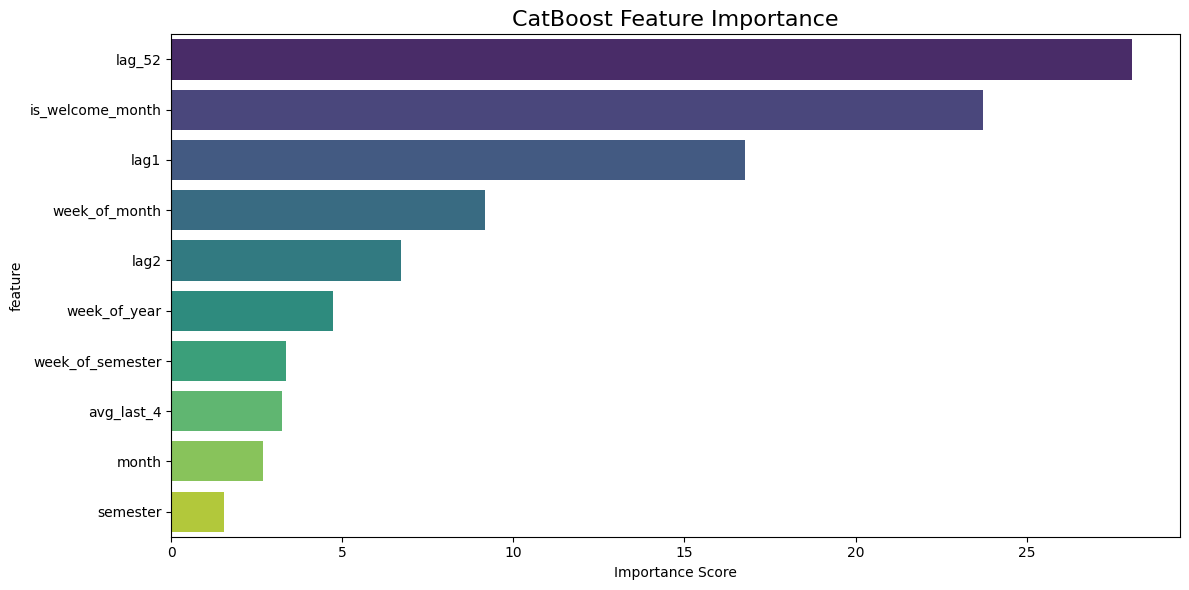

In [17]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis', hue='feature')
plt.title('CatBoost Feature Importance', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

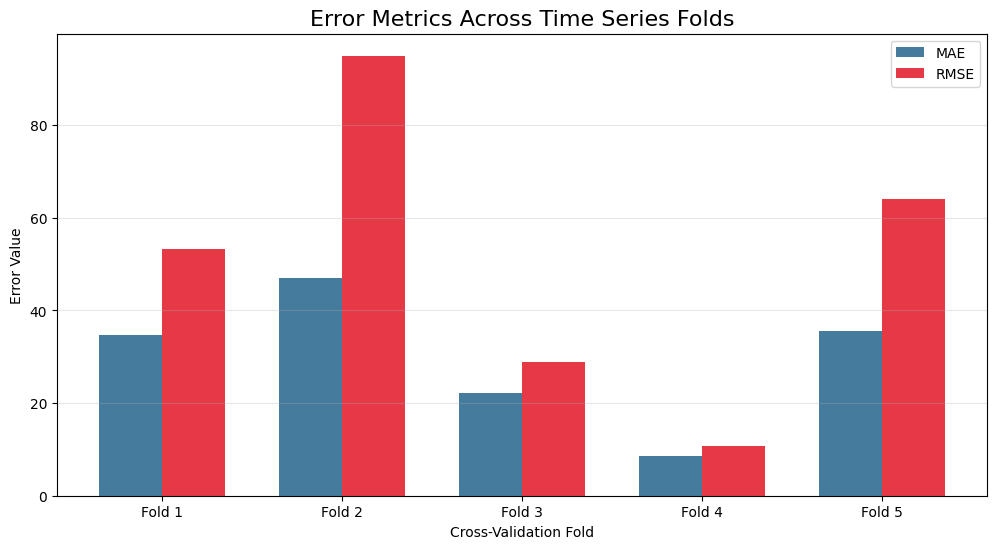

In [18]:
folds = range(1, len(cv_metrics['mae']) + 1)
x = np.arange(len(folds))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, cv_metrics['mae'], width, label='MAE', color='#457b9d')
plt.bar(x + width/2, cv_metrics['rmse'], width, label='RMSE', color='#e63946')

plt.xlabel('Cross-Validation Fold')
plt.ylabel('Error Value')
plt.title('Error Metrics Across Time Series Folds', fontsize=16)
plt.xticks(x, [f'Fold {i}' for i in folds])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()